In [1]:
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import os
path = os.getcwd()

from neurolib.models.e import Model_e
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc
from neurolib.models import jacobian_aln as jac_aln
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [102]:
a = Model_e()
dur_pre = 0.
dur_post = 0.

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

max_it = 1
tol = 1e-30
incl_step = int(1. + a.params.duration/a.params.dt)
test_step = 1e-12

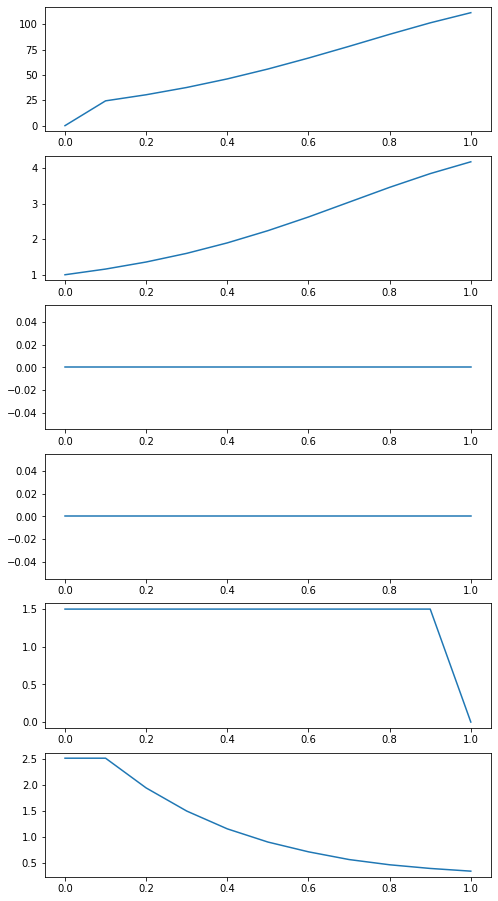

In [105]:
dur = 1.

a.params.duration = dur

target = a.getZeroTarget()
control1 = a.getZeroControl()
a.params.ext_exc_current = 3.

control1[0,0,:] += 2.
#control1[0,0,:] += np.sin(6.*np.arange(0,dur+a.params.dt,a.params.dt))

a.run(control=control1)

target[:,0,:] = a.rates_exc[:,:]

fig, axes = plt.subplots(6, figsize=(8, 16))
axes[0].plot(a.t, a.state["rates_exc"][0,:])
axes[1].plot(a.t, a.state["mufe"][0,:])
axes[2].plot(a.t, a.state["seev"][0,:])
axes[3].plot(a.t, a.state["seem"][0,:])
axes[4].plot(a.t, a.state["sigmae_f"][0,:])
axes[5].plot(a.t, a.state["tau_exc"][0,:])

In [106]:
max_cntrl = 10. * 5.
start_step = 10.
cost_params = [1.0, 2.0, 0.0]

init_state_vars = np.array( [a.params.rates_exc_init, a.params.mufe_init] )
cost.setParams(cost_params[0], cost_params[1], cost_params[2])

control2 = a.getZeroControl()
#control2 += 1.

max_it = 100

A1_bestControlA, A1_bestStateA, A1_costA, runtime = a.A1(control2, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

#0.7262797905237487

set cost params
RUN  0 , total integrated cost =  445.76182702465394
RUN  1 , total integrated cost =  7.323846301137714
RUN  2 , total integrated cost =  4.727646925231513
RUN  3 , total integrated cost =  3.9578036280206614
RUN  4 , total integrated cost =  3.8058952540688074
RUN  5 , total integrated cost =  3.708674981331482
RUN  6 , total integrated cost =  3.6537413506784344
RUN  7 , total integrated cost =  3.618029637359973
RUN  8 , total integrated cost =  3.600730195613462
RUN  9 , total integrated cost =  3.591932837117429
RUN  10 , total integrated cost =  3.5772882752432102
RUN  11 , total integrated cost =  3.5772882752432094
RUN  12 , total integrated cost =  3.577288275243208
State only changes marginally.
Improved over  12  iterations by  99.19748886998228  percent.
final gradient =  [[[0.         0.4220509  0.44871356 0.61369533 0.74376213 0.77402534
   0.70666227 0.51714636 0.94293828 0.7073158  0.        ]]]


[[[0.         1.91868135 1.97469929 2.00171934 2.01136503 2.00600438
   2.00005118 2.00496864 1.99976913 1.86491682 0.        ]]]


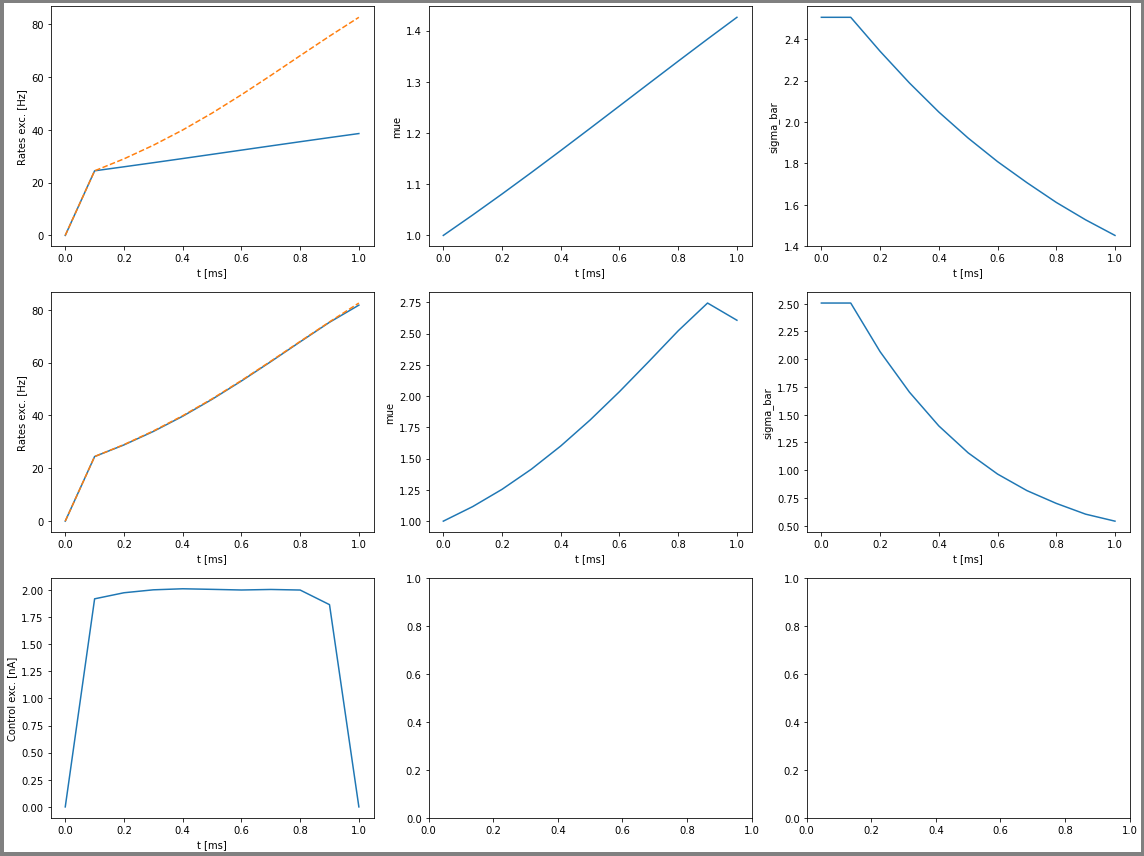

In [70]:
print(A1_bestControlA)
plotFunc.plot_control(a, A1_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'simp')

In [97]:
control3 = control2.copy()
control3[:,:,0] = A1_bestControlA[:,:,0]
control3[:,:,-1] = A1_bestControlA[:,:,-1]

max_it = 60

A2_bestControlA, A2_bestStateA, A2_costA, A2_runtimeA = a.A2(control3, target, max_iteration_ = max_it,
        tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
        max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

start ind =  1
RUN  0 , total integrated cost:  445.76182702465394
Using initial step.
RUN  1 , total integrated cost:  109.6246970196966
RUN  2 , total integrated cost:  13.241372595532717
RUN  3 , total integrated cost:  5.655023370213834
RUN  4 , total integrated cost:  4.780758221085618
RUN  5 , total integrated cost:  4.580242114844911
RUN  6 , total integrated cost:  4.4366619064707615
RUN  7 , total integrated cost:  4.330185951585086
RUN  8 , total integrated cost:  4.2453835435103695
change helped, counter =  1
RUN  9 , total integrated cost:  4.169690475509567
RUN  10 , total integrated cost:  4.101445255691751
change helped, counter =  1
RUN  11 , total integrated cost:  4.035577807997237
change helped, counter =  1
RUN  12 , total integrated cost:  3.9743858239120664
RUN  13 , total integrated cost:  3.9186920856362986
change helped, counter =  2
RUN  14 , total integrated cost:  3.8687419998162076
change helped, counter =  1
RUN  15 , total integrated cost:  3.824457132160

[[[0.         1.94740326 1.98291347 1.98900877 2.01736511 1.97428606
   2.0060062  2.00721042 1.9916696  1.87240644 0.        ]]]


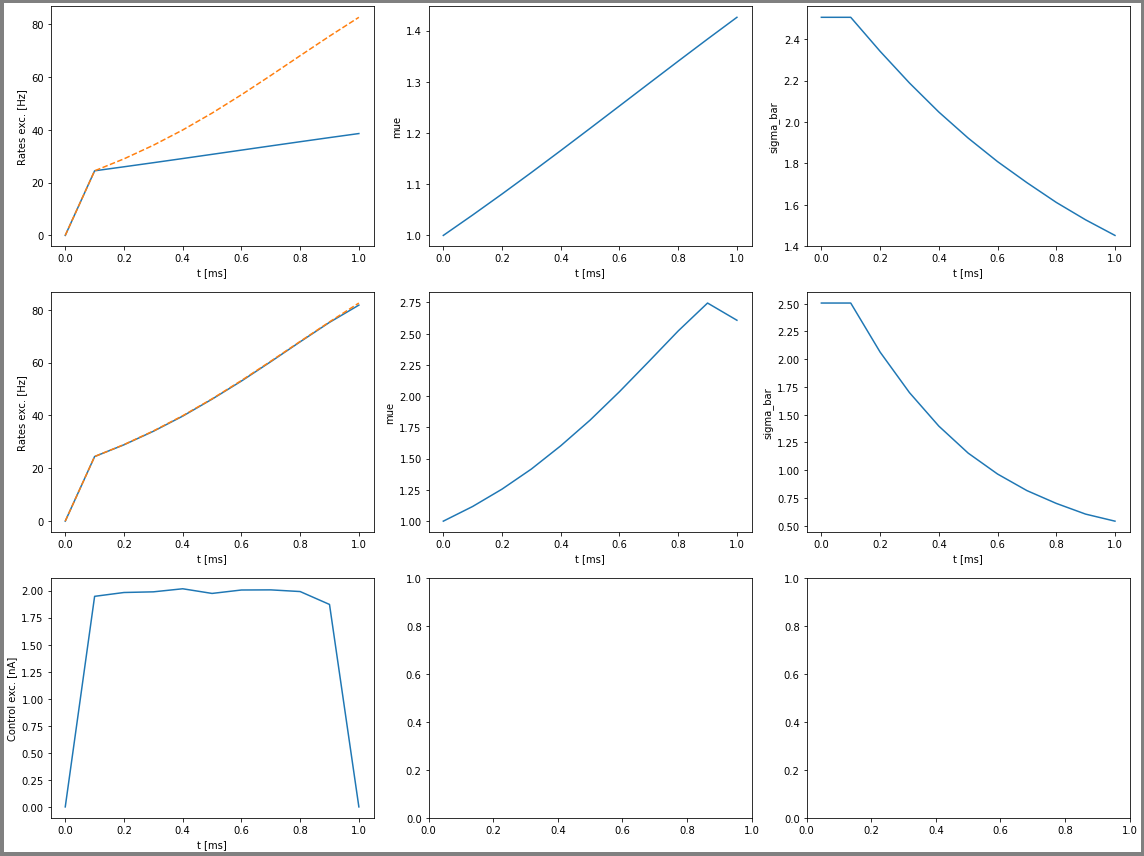

In [72]:
print(A2_bestControlA)
plotFunc.plot_control(a, A2_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'a2simp')

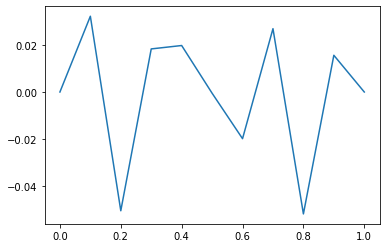

In [80]:
diff = A2_bestControlA[0,0,:] - A1_bestControlA[0,0,:]

plt.plot(a.t, diff)
plt.show()

(350, 64, 2)


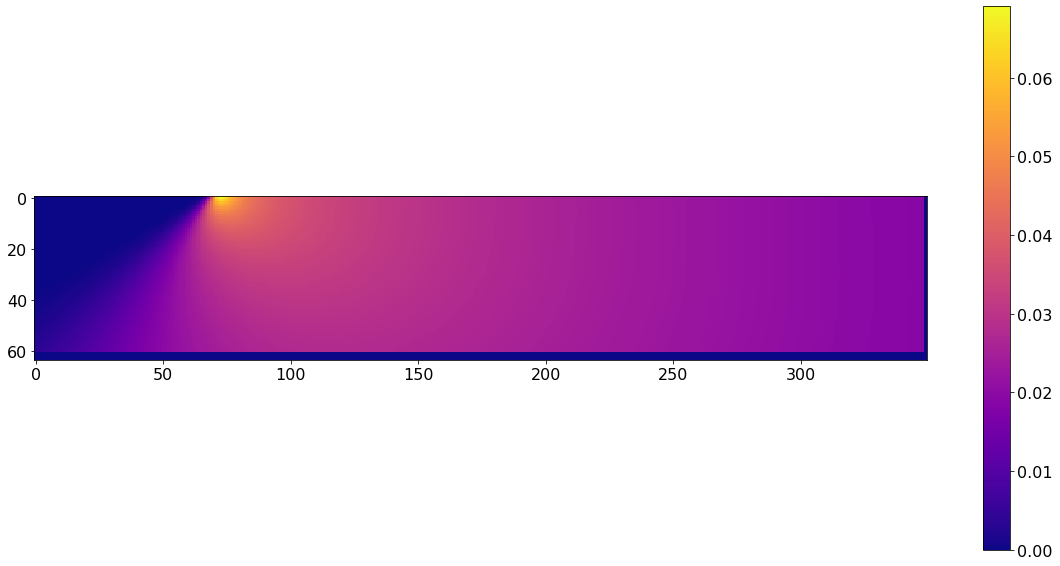

In [332]:
gradient_r = np.zeros(( len(aln.params.Irange), len(aln.params.sigmarange), 2 ))

sigma = aln.params.sigmarange[0]
mu = aln.params.Irange[0]

for sigma in range(len(aln.params.sigmarange)-3):
    for mu in range(len(aln.params.Irange)-1):
        res0 = jac_aln.der_mu(aln, aln.params.sigmarange[sigma], aln.params.Irange[mu], 0, aln.params.precalc_r)
        res1 = jac_aln.der_sigma(aln, aln.params.sigmarange[sigma], aln.params.Irange[mu], 0, aln.params.precalc_r)
        gradient_r[mu, sigma, 0] = res0
        gradient_r[mu, sigma, 1] = res1
        


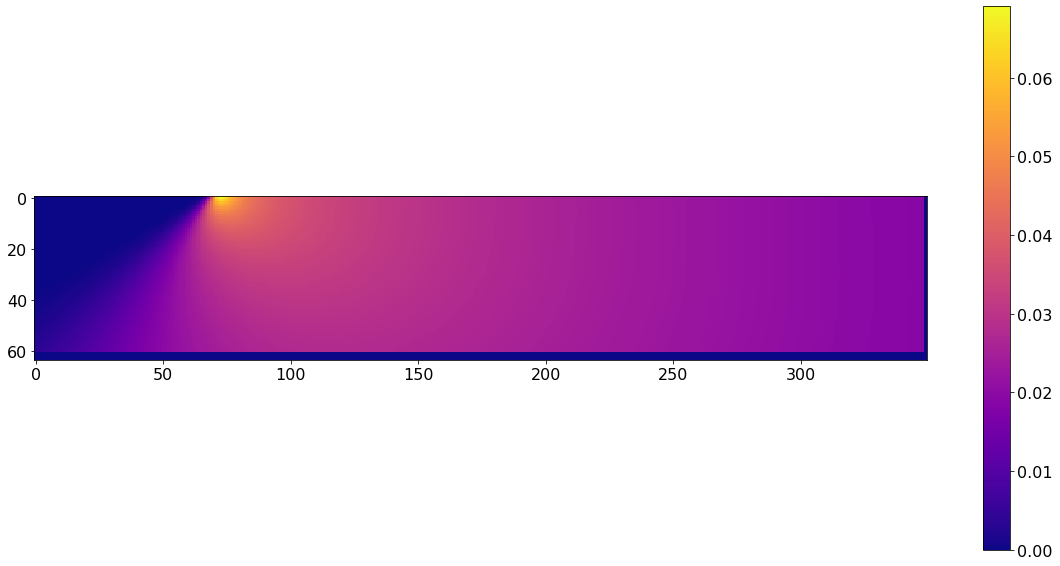

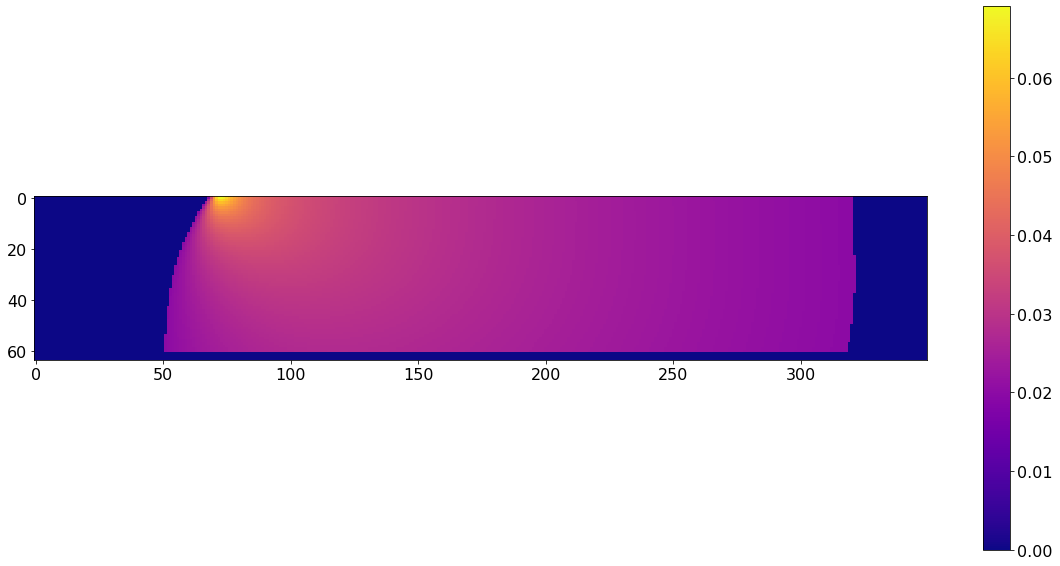

In [336]:
plt.figure(figsize=(20,10))
plt.imshow(gradient_r[:,:,0].T)
plt.colorbar()
plt.show()

threshold = 0.02
large_g = gradient_r.copy()
large_g[large_g < threshold] = 0

plt.figure(figsize=(20,10))
plt.imshow(large_g[:,:,0].T)
plt.colorbar()
plt.show()